In [1]:
import qft_analysis_pqc as qft
import load_circuits as lc
import compile_circuits as cc
import pprint
from qiskit.qasm3 import loads
import pandas as pd
import csv


In [2]:
# Load in data
from pathlib import Path

notebook_dir = Path.cwd()
circuit_data = notebook_dir/ "parity_qc_data" / "circuit_data_fo.json.gz"
fowler_data = notebook_dir / "parity_qc_data" / "fowler_qft_default_data.csv"
heavyhex_data = notebook_dir / "parity_qc_data" / "ibm_boston_heavy_hex_free_layouts_dd.csv"
linear_data = notebook_dir / "parity_qc_data" / "linear_twine_qft_default_data.csv" 

These circuits are the logical Parity Twine QFT circuits. They are not yet run through Fire Opal. These circuits still include gates that are not native to the target hardware. 

 Circuit Ids are from 0 to 579 for each qft_method (580 circuits for each method -> up to 58 qubits (even numbers only) and 20 runs per #qubits). 

In [3]:
circuit_df = qft.process_qft_experiments(circuit_data)

In [4]:
print(circuit_df)

                                     transpiled_circuit        qft_method  \
0     OPENQASM 3.0;\ninclude "stdgates.inc";\nbit[2]...  TwineQFTHeavyHex   
1     OPENQASM 3.0;\ninclude "stdgates.inc";\nbit[2]...  TwineQFTHeavyHex   
2     OPENQASM 3.0;\ninclude "stdgates.inc";\nbit[2]...  TwineQFTHeavyHex   
3     OPENQASM 3.0;\ninclude "stdgates.inc";\nbit[2]...  TwineQFTHeavyHex   
4     OPENQASM 3.0;\ninclude "stdgates.inc";\nbit[2]...  TwineQFTHeavyHex   
...                                                 ...               ...   
1735  OPENQASM 3.0;\ninclude "stdgates.inc";\nbit[58...         FowlerQFT   
1736  OPENQASM 3.0;\ninclude "stdgates.inc";\nbit[58...         FowlerQFT   
1737  OPENQASM 3.0;\ninclude "stdgates.inc";\nbit[58...         FowlerQFT   
1738  OPENQASM 3.0;\ninclude "stdgates.inc";\nbit[58...         FowlerQFT   
1739  OPENQASM 3.0;\ninclude "stdgates.inc";\nbit[58...         FowlerQFT   

         backend  number_of_qubits   basis_state_index  \
0     ibm_boston 

In [5]:
print(circuit_df['qft_method'].value_counts())

qft_method
TwineQFTHeavyHex    580
TwineQFTLinear      580
FowlerQFT           580
Name: count, dtype: int64


In [6]:
# Example: Grabs the very first circuit that belongs to 'FowlerQFT'
#each id number will go from 0 to 579 for each qft method 
circuit = lc.get_circuit(circuit_df, id_number=0, qft_method='TwineQFTHeavyHex')
print(circuit)

OPENQASM 3.0;
include "stdgates.inc";
bit[2] c;
qubit[2] q;
h q[0];
rz(0) q[0];
h q[1];
rz(0) q[1];
rz(pi/2) q[0];
rz(3*pi/4) q[1];
rx(pi/2) q[0];
cx q[1], q[0];
cx q[0], q[1];
rz(-pi/4) q[0];
cx q[1], q[0];
rx(pi/2) q[0];
rz(pi/2) q[0];
rz(3*pi/4) q[1];
c[0] = measure q[0];
c[1] = measure q[1];



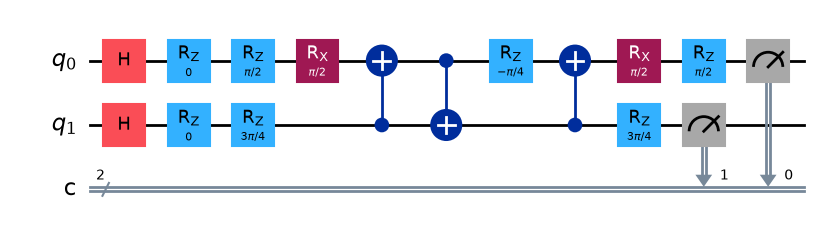

In [7]:
lc.plot_circuit(circuit_df, id_number=0, qft_method='TwineQFTHeavyHex')

In [8]:
#Analyse the circuit
circuit_metrics = lc.analyse_circuit_parameters(circuit)

pprint.pprint(circuit_metrics)

{'circuit_depth': 11,
 'gate_breakdown': {'cx': 3, 'h': 2, 'measure': 2, 'rx': 2, 'rz': 7},
 'num_clbits': 2,
 'num_qubits': 2,
 'one_qubit_gate_count': 13,
 'total_gate_count': 16,
 'two_qubit_gate_count': 3}


## Loading The Fidelity Results 

The circuits only go up to using 58 qubits whereas the fidelity results go up to 60 qubits, so we are only interested in saving the fidelities and number of qubits up to and including the runs on 58 qubits. 

In [9]:
with open(heavyhex_data) as f:
    reader = csv.reader(f)
    columns_as_lists = [list(c) for c in zip(*reader)]

fidelity_heavyhex = columns_as_lists[2][1:581]
no_qubits_heavyhex = columns_as_lists[0][1:581]

print(len(fidelity_heavyhex))

580


In [10]:
with open(linear_data) as f: 
    reader = csv.reader(f)
    columns_as_lists = [list(c) for c in zip(*reader)]

fidelity_linear = columns_as_lists[2][1:581]
no_qubits_linear_= columns_as_lists[0][1:581]

print(len(fidelity_linear))

580


In [11]:
with open(fowler_data) as f: 
    reader = csv.reader(f)
    columns_as_lists = [list(c) for c in zip(*reader)]  

fidelity_fowler = columns_as_lists[2][1:581]
no_qubits_fowler = columns_as_lists[0][1:581]

print(len(fidelity_fowler))

580


In [12]:
#function to store circuit metrics in a dictionary indexed by circuit ID, qft method, fidelity, and number of qubits

def store_circuits_in_dict(
    circuit_ids: list, qft_types: list, fidelities: list, n_qubits: list
) -> dict:
    """Combines circuit metrics into a structured dictionary indexed by Circuit

    ID.
    """
    circuit_dict = {}

    # zip handles the parallel list parsing
    for cid, qft, fid, nq in zip(circuit_ids, qft_types, fidelities, n_qubits):
        # We save the data as a nested dictionary under the circuit ID key
        circuit_dict[cid] = {"qft_type": qft, "fidelity": fid, "n_qubits": nq}

    return circuit_dict


In [13]:
#loop over like this to store into separate dictionaries for each circuit ID, qft method, fidelity, and number of qubits
for i in range(21):
    print(store_circuits_in_dict(circuit_ids= [i], qft_types = ['TwineQFTHeavyHex'], fidelities = [float(fidelity_heavyhex[i])], n_qubits= [int(no_qubits_heavyhex[i])]))

{0: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9858727578898789, 'n_qubits': 2}}
{1: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9838702326349049, 'n_qubits': 2}}
{2: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9849961479931998, 'n_qubits': 2}}
{3: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9848211049059495, 'n_qubits': 2}}
{4: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.986272144456975, 'n_qubits': 2}}
{5: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9852213194913224, 'n_qubits': 2}}
{6: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9838456314478194, 'n_qubits': 2}}
{7: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9852981357843169, 'n_qubits': 2}}
{8: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.984769471764023, 'n_qubits': 2}}
{9: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9848212198405659, 'n_qubits': 2}}
{10: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9874228196619352, 'n_qubits': 2}}
{11: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.98551879859612

In [14]:
#alternatively, you can store all the circuit metrics in a single dictionary by passing lists of all the circuit IDs, qft methods, fidelities, and number of qubits to the function
#but remember to update for whatever range of circuit IDs you want to store in the dictionary (e.g., 0-20 for the first 21 circuits)
print(store_circuits_in_dict(circuit_ids= [i for i in range(21)], 
                             qft_types = ['TwineQFTHeavyHex'] * 21, 
                             fidelities = [float(fidelity_heavyhex[i]) for i in range(21)], 
                             n_qubits= [int(no_qubits_heavyhex[i]) for i in range(21)]))

{0: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9858727578898789, 'n_qubits': 2}, 1: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9838702326349049, 'n_qubits': 2}, 2: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9849961479931998, 'n_qubits': 2}, 3: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9848211049059495, 'n_qubits': 2}, 4: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.986272144456975, 'n_qubits': 2}, 5: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9852213194913224, 'n_qubits': 2}, 6: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9838456314478194, 'n_qubits': 2}, 7: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9852981357843169, 'n_qubits': 2}, 8: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.984769471764023, 'n_qubits': 2}, 9: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9848212198405659, 'n_qubits': 2}, 10: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9874228196619352, 'n_qubits': 2}, 11: {'qft_type': 'TwineQFTHeavyHex', 'fidelity': 0.9855187985961242, 'n_qubi

## Compile the Circuits 

In [15]:
example_circuit = lc.get_circuit(circuit_df, id_number=0, qft_method='TwineQFTHeavyHex')

In [16]:
#compile using qiskit compiler 
compiled_circuit = cc.compile_qasm_string(example_circuit, backend=None)


In [17]:
print(compiled_circuit)

OPENQASM 3.0;include "stdgates.inc";bit[2] c;qubit[2] q;u1(-pi/2) q[0];u2(3*pi/4, -pi) q[1];cx q[1], q[0];cx q[0], q[1];rz(-pi/4) q[0];cx q[1], q[0];rx(pi/2) q[0];c[0] = measure q[0];c[1] = measure q[1];


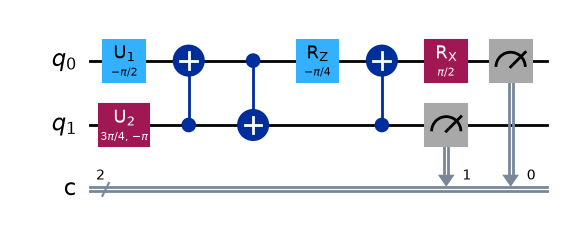

In [18]:
# 1. Turn your string back into a Qiskit circuit object
circuit_to_plot = loads(compiled_circuit)

# 2. Plot it beautifully
circuit_to_plot.draw('mpl')

In [21]:
compiled_circuit_metrics = lc.analyse_circuit_parameters(compiled_circuit)
print(compiled_circuit_metrics)

{'num_qubits': 2, 'num_clbits': 2, 'circuit_depth': 7, 'total_gate_count': 9, 'two_qubit_gate_count': 3, 'one_qubit_gate_count': 6, 'gate_breakdown': {'cx': 3, 'measure': 2, 'u1': 1, 'u2': 1, 'rz': 1, 'rx': 1}}
